In [1]:
import pandas
import numpy
import matplotlib
import sklearn

print("All libraries installed successfully!")

All libraries installed successfully!


In [8]:
import pandas as pd

print("Loading dataset...")

df = pd.read_csv("Online Retail.csv")

print("Loaded successfully!")
print(df.shape)

df.head()

Loading dataset...
Loaded successfully!
(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/10 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/10 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/10 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/10 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/10 8:26,3.39,17850.0,United Kingdom


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [10]:
# Remove rows with missing CustomerID
df = df.dropna(subset=['CustomerID'])

# Remove cancelled orders
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Convert InvoiceDate to datetime
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Create Sales column
df['Sales'] = df['Quantity'] * df['UnitPrice']

print("Dataset Shape After Cleaning:", df.shape)

C:\Users\rodda\AppData\Local\Temp\ipykernel_26508\2232319241.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])


Dataset Shape After Cleaning: (397924, 9)


In [11]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Sales          0
dtype: int64


In [12]:
daily_sales = df.groupby(
    df['InvoiceDate'].dt.date
)['Sales'].sum().reset_index()

daily_sales.columns = ['Date', 'Sales']

daily_sales['Date'] = pd.to_datetime(
    daily_sales['Date']
)

print(daily_sales.head())
print(daily_sales.shape)

        Date     Sales
0 2010-12-01  46376.49
1 2010-12-02  47316.53
2 2010-12-03  23921.71
3 2010-12-05  31771.60
4 2010-12-06  31215.64
(305, 2)


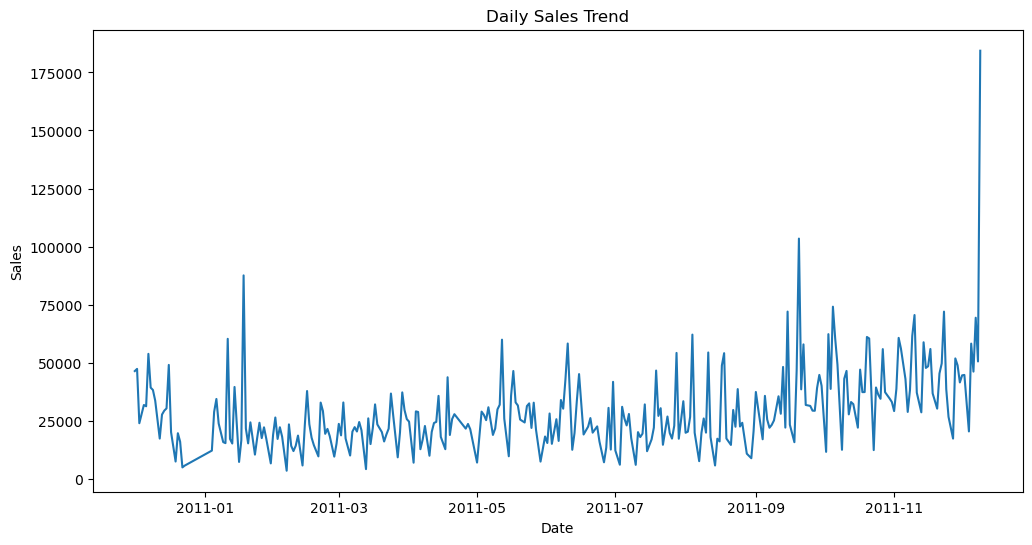

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    daily_sales['Date'],
    daily_sales['Sales']
)

plt.title('Daily Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales')

plt.show()

In [14]:
daily_sales['Year'] = daily_sales['Date'].dt.year
daily_sales['Month'] = daily_sales['Date'].dt.month
daily_sales['Day'] = daily_sales['Date'].dt.day
daily_sales['DayOfWeek'] = daily_sales['Date'].dt.dayofweek

daily_sales.head()

,Date,Sales,Year,Month,Day,DayOfWeek
0,2010-12-01,46376.49,2010,12,1,2
1,2010-12-02,47316.53,2010,12,2,3
2,2010-12-03,23921.71,2010,12,3,4
3,2010-12-05,31771.60,2010,12,5,6
4,2010-12-06,31215.64,2010,12,6,0


In [15]:
X = daily_sales[
    ['Year','Month','Day','DayOfWeek']
]

y = daily_sales['Sales']

print(X.shape)
print(y.shape)

(305, 4)
(305,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print(X_train.shape)
print(X_test.shape)

(244, 4)
(61, 4)


In [17]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


In [18]:
y_pred = model.predict(X_test)

print("Predictions Generated Successfully")

Predictions Generated Successfully


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 17003.76792180328
Root Mean Squared Error (RMSE): 27110.18831452503
R² Score: -0.3691612910626507


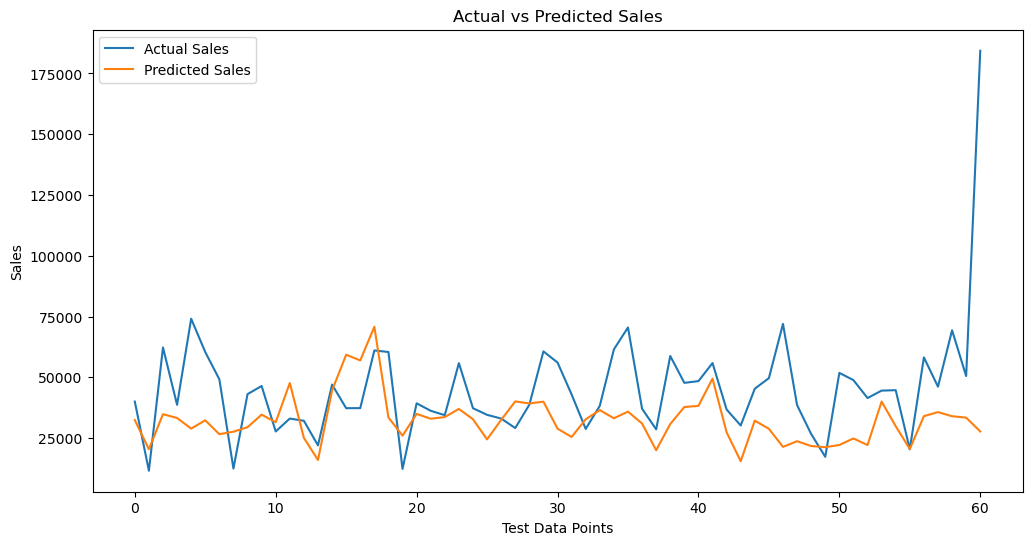

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label='Actual Sales')
plt.plot(y_pred, label='Predicted Sales')

plt.title('Actual vs Predicted Sales')
plt.xlabel('Test Data Points')
plt.ylabel('Sales')
plt.legend()

plt.savefig('actual_vs_predicted.png')

plt.show()

In [21]:
future_dates = pd.date_range(
    start=daily_sales['Date'].max() + pd.Timedelta(days=1),
    periods=30
)

future_df = pd.DataFrame({
    'Year': future_dates.year,
    'Month': future_dates.month,
    'Day': future_dates.day,
    'DayOfWeek': future_dates.dayofweek
})

future_predictions = model.predict(future_df)

print(future_predictions[:10])

[31742.1612  27631.9111  30399.1036  38783.8522  30814.505   51572.3783
 25902.8     25573.0263  15138.51791 40319.14904]


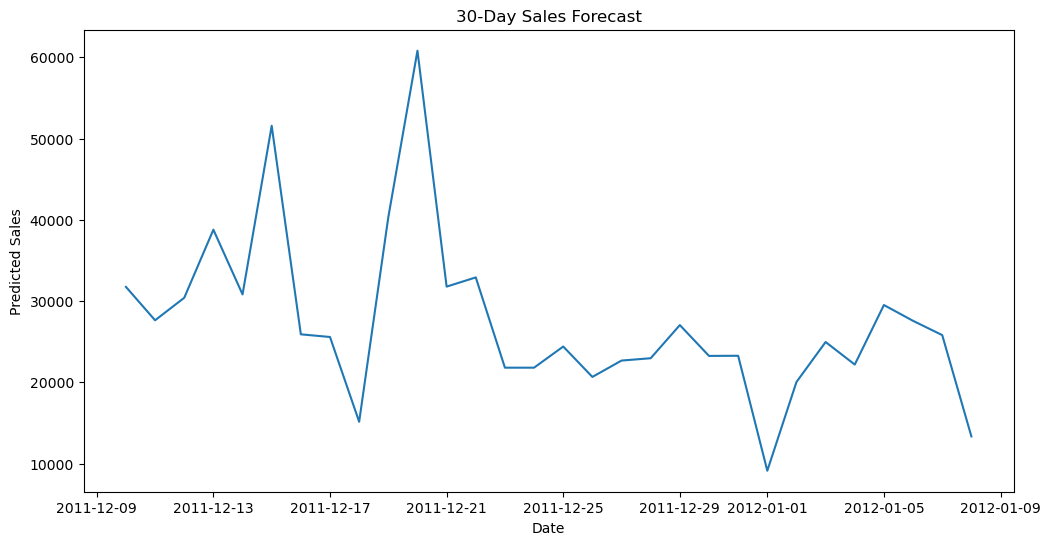

In [22]:
plt.figure(figsize=(12,6))

plt.plot(
    future_dates,
    future_predictions
)

plt.title('30-Day Sales Forecast')
plt.xlabel('Date')
plt.ylabel('Predicted Sales')

plt.savefig('forecast.png')

plt.show()